## Correlating Gini and M20 Coefficients.
This Notebook takes the results from the HEC of the Gini and M20 calculations and looks for their correlations in the different samples.

### Imports

In [203]:
import os
import pandas as pd
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

from tqdm import tqdm

from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.nddata import Cutout2D
from astropy.visualization import MinMaxInterval, SqrtStretch, ImageNormalize

from shapely.geometry import Point, Polygon

from IPython.display import clear_output

### Looking at Merger Sample

In [2]:
data_folder = 'C:/Users/dorya/OneDrive - Lancaster University/personal-pc-phd-work/galaxy-zoo-desi/data'
folder = 'D:/GZ-DESI/data'
df_int = pd.read_parquet(f'{folder}/2023-03-15-cats/definitive-merged-interesting-params.parquet', engine = 'pyarrow')[['id_str', 'redshift']]

In [3]:
df_gini = pd.read_csv(f'{data_folder}/ginis-mergers.csv', index_col = 0)
df_m20 = pd.read_csv(f'{data_folder}/m20s-merger.csv', index_col = 0)

In [4]:
df_m20.columns

Index(['id_str', 'ra', 'dec', 'est_petro_th50', 'hec_path', 'm20'], dtype='object')

In [5]:
df_m20_red = (
    df_m20[['id_str', 'm20']]
)

In [6]:
df_merge = df_gini.merge(df_m20_red, on = 'id_str', how = 'left')

In [7]:
del df_gini, df_m20, df_m20_red

In [8]:
df_sele = df_merge.query('gini_r != "partial-overlap" and gini_r != "empty-image" and gini_r != "corrupted" and gini_r != "Failed" and gini_r != "no-galaxy"')

In [9]:
df_tmp = (
    df_sele
    .assign(gini_r_int = df_sele.gini_r.apply(lambda x: float(x)))
)

In [10]:
df_float = (
    df_tmp
    .assign(m20_int = df_tmp.m20.apply(lambda x: float(x)))
)

In [11]:
norm_line = [
    [-0.6, 0.45],
    [-3,0.71]
]
norm_arr = np.asarray(norm_line)

In [12]:
norm_arr[:,0]

array([-0.6, -3. ])

In [13]:
df_merge = df_float.merge(df_int, on = 'id_str', how = 'left').dropna()

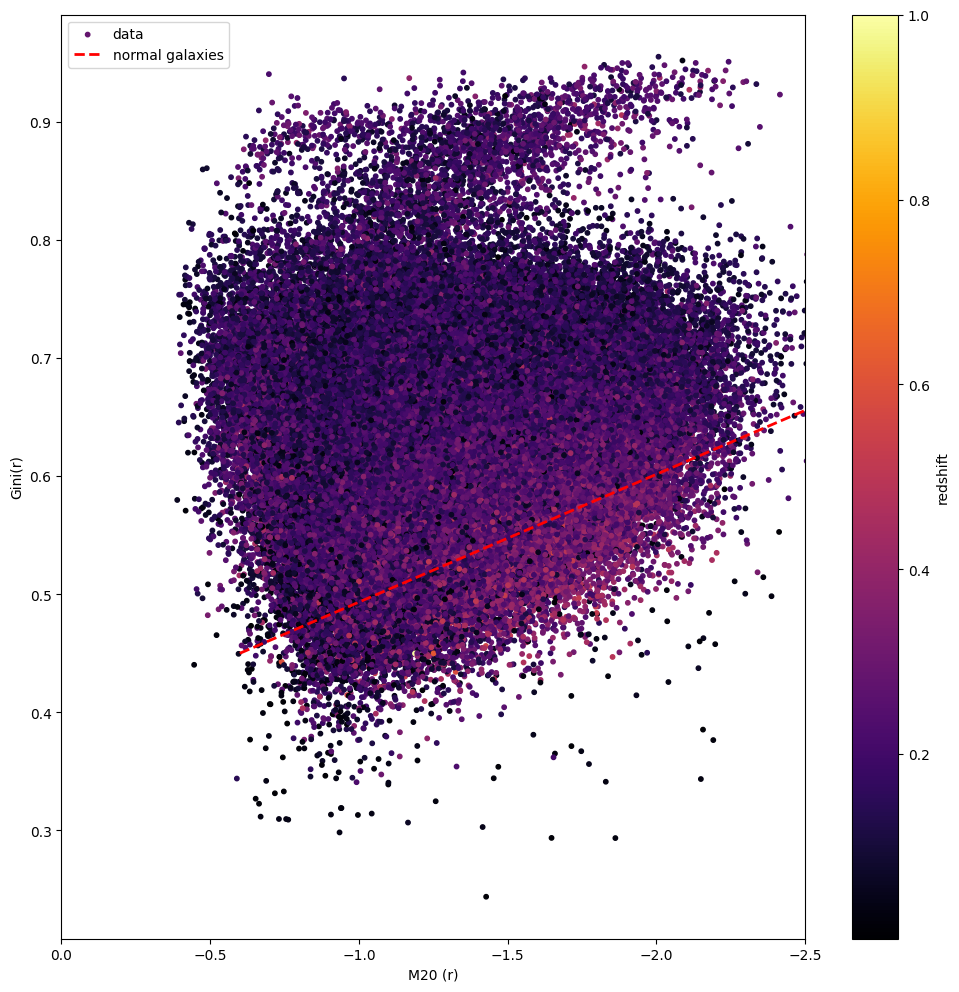

In [14]:
fig, ax1 = plt.subplots(nrows = 1)
df_merge.plot.scatter(
    x = 'm20_int',
    y = 'gini_r_int',
    c = 'redshift',
    colormap = 'inferno',
    colorbar=True,
    figsize = (12,12),
    s = 10,
    # alpha = 0.01,
    xlim = [0, -2.5],
    ylabel = 'Gini(r)',
    xlabel = 'M20 (r)',
    ax = ax1,
    label = 'data'
)

ax1.plot(norm_arr[:,0], norm_arr[:,1], color = 'red', linestyle='dashed', linewidth = 2.0, label = 'normal galaxies')
plt.legend()

plt.show()

### Making Digitised Plot

In [15]:
def getting_correct_contours(contours, cen_x, cen_y):
    point = Point(cen_x, cen_y)        
    for i in contours:
        cont_arr = conts_to_arr(i)
        if len(cont_arr) > 2:
            polygon = Polygon(cont_arr)
            if polygon.contains(point):
                return cont_arr
            else:
                continue
        else:
            continue
        
    return 'failed'

In [16]:
def conts_to_arr(nested_list):
    contour_arr = np.zeros([len(nested_list),2])
    for i in range(len(nested_list)):
        row = nested_list[i][0]
        contour_arr[i,0] = row[0]
        contour_arr[i,1] = row[1]
    
    return contour_arr

In [205]:
def show_thumbnails(df, num_bins=50):
    _, hx, hy = np.histogram2d(list(df.gini_r_int), list(df.m20_int), bins=[num_bins, num_bins])
    
    hx_indices = np.digitize(list(df.gini_r_int), hx)
    hy_indices = np.digitize(list(df.m20_int), hy)
    h_indices = np.stack([hx_indices, hy_indices], axis = 1)
    
    
    image_map = {}
    for image_loc, indices in zip(df['local_paths'], h_indices):
        image_map[tuple(indices)] = image_loc
    
    fig,axes = plt.subplots(ncols=num_bins+1, nrows = num_bins+1, figsize=(35,35))
    
    for row in axes:
        for ax in row:
            ax.axis('off')
    
    for indices, image_loc in image_map.items():
        ax = axes[indices[0] - 1, indices[1]-1]
        
        data = fits.getdata(image_loc)
        header = fits.getheader(image_loc)
        
        tmp = df.query('local_paths == @image_loc')
        ra = tmp.ra.iloc[0]
        dec = tmp.dec.iloc[0]
        
        cutout = data[1,:,:]
        
        norm = ImageNormalize(cutout, interval = MinMaxInterval(), stretch = SqrtStretch())
        
#         w = WCS(header, naxis = 2)

#         size = u.Quantity((10*petro_50, 10*petro_50), u.arcsec)
#         coord = SkyCoord(ra = ra * u.deg, dec = dec * u.deg, frame = 'icrs')
#         cutout = Cutout2D(data, coord, size, wcs = w, mode='strict')

        cutout_int = cutout.copy()
        cut = np.percentile(cutout,80)
        cutout_int[cutout_int <= cut] = 0
        cutout_int[cutout_int > cut] = 1
        cutout_int = cutout_int.astype(int)
        
        contours, _ = cv.findContours(cutout_int, cv.RETR_FLOODFILL, cv.CHAIN_APPROX_NONE)
        contour_arr = getting_correct_contours(contours, int(cutout.shape[0]/2), int(cutout.shape[1]/2))

        
        ax.imshow(cutout, cmap='gray', origin = 'lower', norm = norm)
        ax.plot(contour_arr[:,0], contour_arr[:,1])
        clear_output(wait = True)
        ax.axis('off')
        
        del data, header, tmp
    
    fig.tight_layout(pad = 0.0)
    fig.text(0.01, 0.5, 'Gini (r)', ha='center', va='center', rotation='vertical', fontsize = 24)
    fig.text(0.5, 0.01, 'M20 (r)', ha='center', va='center', fontsize = 24)
    # fig.savefig('C:/Users/oryan/Documents/mergers_in_desi/images/digitized-gini-m20-dist.jpeg')

In [206]:
df_digi = (
    df_float
    .drop(columns = 'hec_path')
    .assign(local_paths = df_float.id_str.apply(lambda x: f'D:/GZ-DESI/images/mergers/{x}-cutout.fits'))
    .dropna()
    .query('m20_int > -1e20')
)

Wall time: 1min 53s


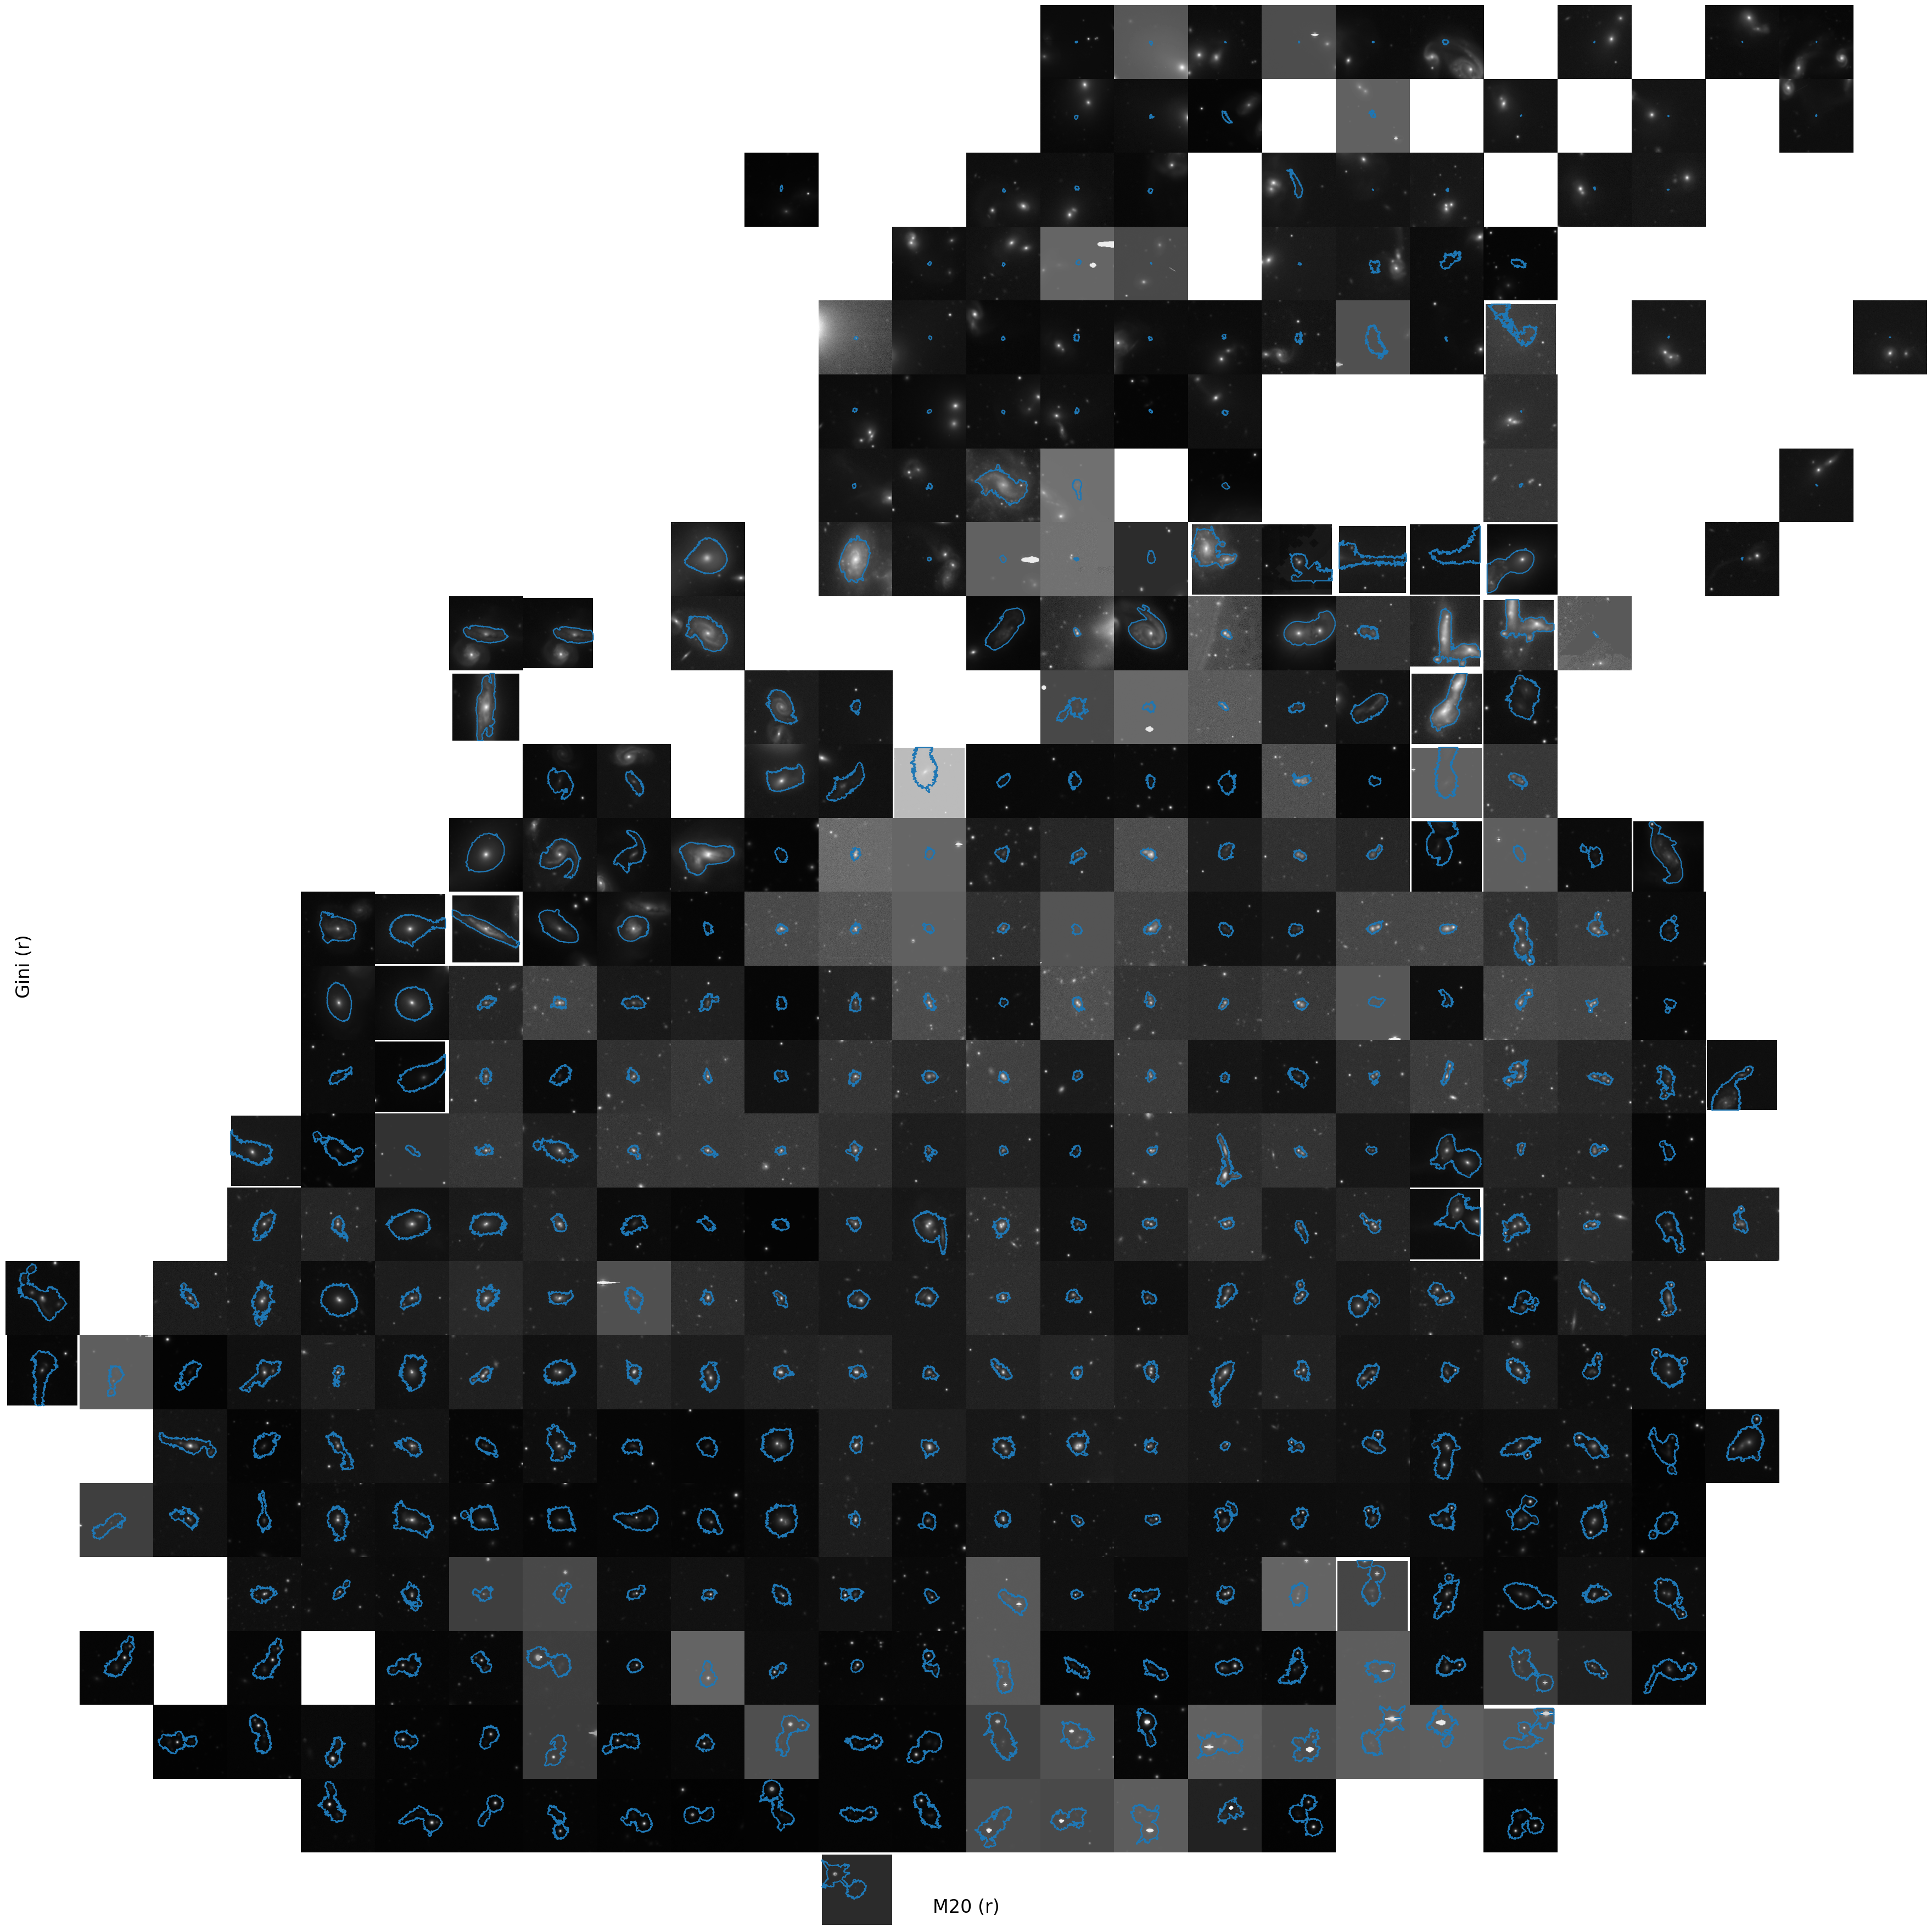

In [207]:
%%time
show_thumbnails(df_digi, num_bins = 25)

In [20]:
df_float.head()

,id_str,ra,dec,est_petro_th50,hec_path,gini_r,m20,gini_r_int,m20_int
0,390393_113,315.670729,10.126369,1.892756,/mmfs1/scratch/hpc/60/oryan/desi-mergers/39039...,0.6362102124846234,-1.9609348583190795,0.636210,-1.960935
1,388975_4015,315.879343,10.010424,1.708224,/mmfs1/scratch/hpc/60/oryan/desi-mergers/38897...,0.6579679616054532,-1.1471908247403892,0.657968,-1.147191
2,388975_4016,315.878811,10.011117,1.472603,/mmfs1/scratch/hpc/60/oryan/desi-mergers/38897...,0.6449185208779499,-1.1180917765101586,0.644919,-1.118092
3,388976_4771,316.075869,10.014121,1.637970,/mmfs1/scratch/hpc/60/oryan/desi-mergers/38897...,0.9216357472906815,-1.7775355822498993,0.921636,-1.777536
4,390397_3464,316.671962,10.263765,1.599376,/mmfs1/scratch/hpc/60/oryan/desi-mergers/39039...,0.7375211205198876,-1.1718156449212571,0.737521,-1.171816


### Controlling for Redshift

In [21]:
folder = 'D:/GZ-DESI/data'
df_int = pd.read_parquet(f'{folder}/2023-03-15-cats/definitive-merged-interesting-params.parquet', engine = 'pyarrow')

In [22]:
df_int.columns

Index(['id_str', 'merging_none_fraction', 'merging_minor-disturbance_fraction',
       'merging_major-disturbance_fraction', 'merging_merger_fraction',
       'category', 'ra', 'dec', 'log_l_ha', 'log_l_oiii', 'photo_z', 'spec_z',
       'redshift', 'redshift_nsa', 'total_sfr_avg', 'elpetro_mass', 'logMH',
       'elpetro_mass_log', 'log_m_bh', 'log_bolometric_l'],
      dtype='object')

In [23]:
df_red = df_int[['id_str', 'redshift']]
del df_int

In [24]:
df_red.redshift.max()

1.0

In [25]:
df_merge = df_float.merge(df_red, on = 'id_str', how = 'left')

In [26]:
df_merge.m20_int.min()

-inf

### Looking at Redshift z < 0.1

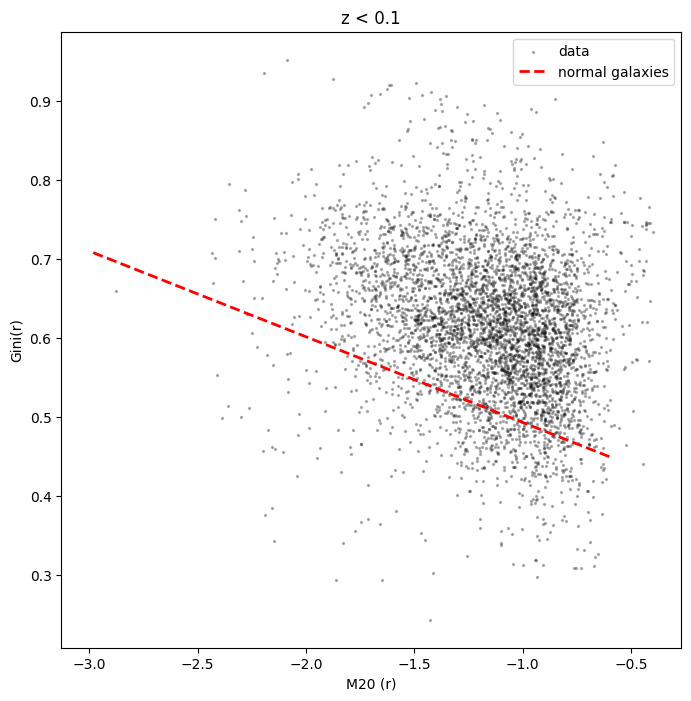

In [201]:
fig, ax1 = plt.subplots(nrows = 1)
df_merge.query('redshift < 0.05').plot.scatter(
    x = 'm20_int',
    y = 'gini_r_int',
    figsize = (8,8),
    s = 2,
    alpha = 0.25,
    color = 'black',
    ylabel = 'Gini(r)',
    xlabel = 'M20 (r)',
    title = 'z < 0.1',
    ax = ax1,
    label = 'data'
)

ax1.plot(norm_arr[:,0], norm_arr[:,1], color = 'red', linestyle='dashed', linewidth = 2.0, label = 'normal galaxies')
plt.legend()

plt.show()

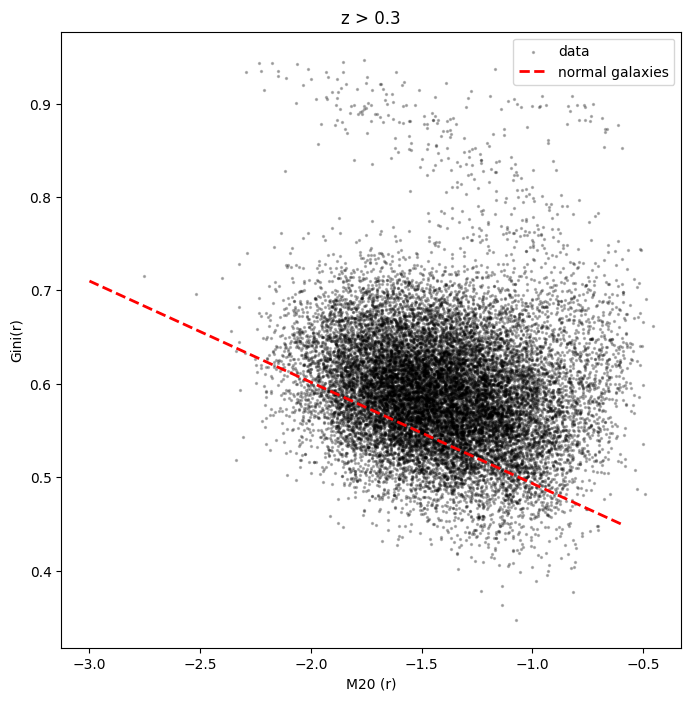

In [208]:
fig, ax1 = plt.subplots(nrows = 1)
df_merge.query('redshift > 0.3').plot.scatter(
    x = 'm20_int',
    y = 'gini_r_int',
    figsize = (8,8),
    s = 2,
    alpha = 0.25,
    color = 'black',
    ylabel = 'Gini(r)',
    xlabel = 'M20 (r)',
    ax = ax1,
    title = 'z > 0.3',
    label = 'data'
)

ax1.plot(norm_arr[:,0], norm_arr[:,1], color = 'red', linestyle='dashed', linewidth = 2.0, label = 'normal galaxies')
plt.legend()

plt.show()

### Measuring Change in Redshift

In [121]:
norm_arr

array([[-0.6 ,  0.45],
       [-3.  ,  0.71]])

In [122]:
d1 = np.array([-3,0.71])
d2 = np.array([-0.6, 0.45])

In [124]:
m = (d1[1] - d2[1]) / (d1[0] - d2[0])

In [126]:
c = d1[1] - (d1[0]*m)

In [172]:
redshift_bins = np.linspace(0,1,50)

In [173]:
df_merge.columns

Index(['id_str', 'ra', 'dec', 'est_petro_th50', 'hec_path', 'gini_r', 'm20',
       'gini_r_int', 'm20_int', 'redshift'],
      dtype='object')

In [174]:
def expected_val(m, c, x):
    return m*x + c

In [175]:
def frac_above(df, m, c):
    
    if len(df) < 0.5:
        return np.nan
    
    df_dec = (
        df.assign(below = df.apply(lambda row: True if expected_val(m, c, row.m20_int) > row.gini_r_int else False, axis = 1))
    )
    
    frac_below = df_dec.below.sum() / len(df_dec)
    
    return frac_below

In [176]:
redshift_dict = {}
for i in tqdm(redshift_bins):
    redshift_dict[i] = frac_above(df_merge[['gini_r_int', 'm20_int', 'redshift']].query('redshift > @i'), m, c)

100%|██████████| 50/50 [00:46<00:00,  1.08it/s]


In [192]:
df_cuts = pd.DataFrame.from_dict(redshift_dict, orient = 'index').reset_index().rename(columns = {0 : 'fraction_below', 'index' : 'redshift-cut'})

In [196]:
numbers_bins = {}
for i in tqdm(redshift_bins):
    numbers_bins[i] = len(df_merge[['gini_r_int', 'm20_int', 'redshift']].query('redshift > @i')) / len(df_merge)
    
df_nums = pd.DataFrame.from_dict(numbers_bins, orient = 'index').reset_index().rename(columns = {0 : 'n-sources', 'index' : 'redshift-cut'})

100%|██████████| 50/50 [00:00<00:00, 124.83it/s]


Text(0, 0.5, 'Fraction of Sources')

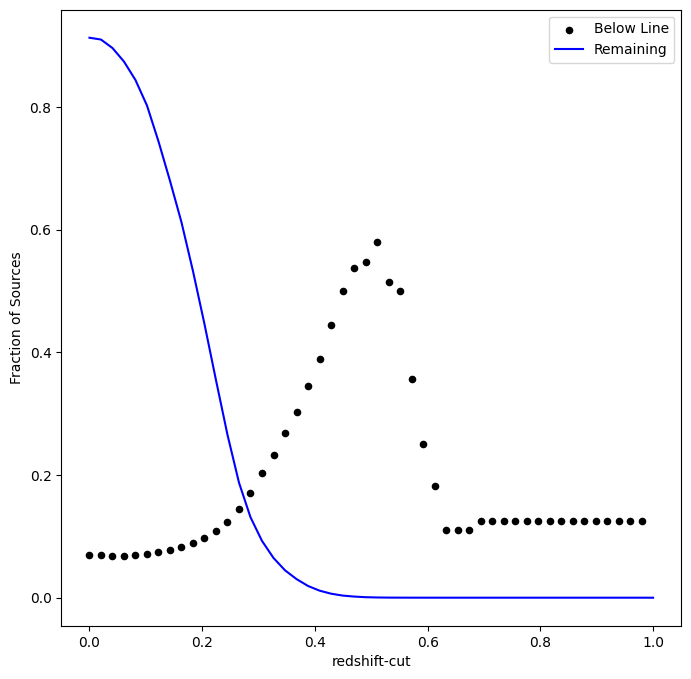

In [202]:
fig = plt.figure(figsize = (8,8))

ax1 = fig.add_subplot(111)
df_cuts.plot.scatter(
    x = 'redshift-cut',
    y = 'fraction_below',
    color = 'black',
    ax = ax1,
    label = 'Below Line'
)

df_nums.plot(
    x = 'redshift-cut',
    y = 'n-sources',
    color = 'blue',
    ax = ax1,
    label = 'Remaining',
    
)

plt.ylabel('Fraction of Sources')

In [211]:
df_merge[['id_str', 'ra', 'dec', 'est_petro_th50', 'gini_r_int', 'm20_int', 'redshift']].rename(columns = {'m20_int' : 'm20', 'gini_r_int' : 'gini'}).to_csv(r'C:\Users\dorya\OneDrive - Lancaster University\personal-pc-phd-work\galaxy-zoo-desi\results\gini-m20-merger.csv')